MLP

In [1]:

import numpy as np
import pandas as pd
DATA_PATH = r"C:\Users\Papabizz\1. a Python\Ch 2\NN Practice\hospital_deterioration_hourly_panel.csv"
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print(df.head(3))

df = df.sort_values(["patient_id", "hour_from_admission"]).reset_index(drop=True)

Shape: (417866, 28)
   patient_id  hour_from_admission  heart_rate  respiratory_rate  spo2_pct  \
0           1                    0       68.58             14.47     96.52   
1           1                    1       67.03             13.87     94.94   
2           1                    2       69.05             14.63     94.45   

   temperature_c  systolic_bp  diastolic_bp oxygen_device  oxygen_flow  ...  \
0          37.18       108.94         78.43          none          0.0  ...   
1          37.25       111.73         79.14          none          0.0  ...   
2          37.29       111.48         78.86          none          0.0  ...   

   age  gender  comorbidity_index  admission_type  baseline_risk_score  \
0   24       M                  2        Elective               0.2173   
1   24       M                  2        Elective               0.2173   
2   24       M                  2        Elective               0.2173   

   los_hours  deterioration_event  deterioration_with

In [2]:
non_mono = (
    df.groupby("patient_id")["hour_from_admission"]
      .apply(lambda s: not s.is_monotonic_increasing)
      .sum()
)
print("Patients with non-monotonic time:", int(non_mono))

Patients with non-monotonic time: 0


In [3]:
mask_event = df["deterioration_hour"] >= 0
df = df[~(mask_event & (df["hour_from_admission"] >= df["deterioration_hour"]))].copy()

print("After dropping post-event rows:", df.shape)
print("Hourly y rate (overall):", df["deterioration_next_12h"].mean())

After dropping post-event rows: (382548, 28)
Hourly y rate (overall): 0.059048799104948924


In [4]:
patient_table = (
    df.groupby("patient_id", as_index=False)
      .agg(deterioration_event=("deterioration_event", "max"))
)

patient_ids = patient_table["patient_id"].to_numpy()
patient_strata = patient_table["deterioration_event"].to_numpy()

print("Total patients:", len(patient_ids))
print("Patient event rate (for stratify):", patient_strata.mean())

Total patients: 10000
Patient event rate (for stratify): 0.1938


In [5]:
from sklearn.model_selection import train_test_split

trainval_ids, test_ids = train_test_split(
    patient_ids,
    test_size=0.20,
    random_state=42,
    stratify=patient_strata
)

trainval_ids = set(trainval_ids)
test_ids = set(test_ids)

df_trainval = df[df["patient_id"].isin(trainval_ids)].copy()
df_test     = df[df["patient_id"].isin(test_ids)].copy()

print("Trainval patients:", len(trainval_ids))
print("Test patients:", len(test_ids))
print("Trainval rows:", df_trainval.shape)
print("Test rows:", df_test.shape)

overlap = set(df_trainval["patient_id"].unique()) & set(df_test["patient_id"].unique())
print("Patient overlap trainval vs test:", len(overlap))

print("Hourly y rate trainval:", df_trainval["deterioration_next_12h"].mean())
print("Hourly y rate test:", df_test["deterioration_next_12h"].mean())

Trainval patients: 8000
Test patients: 2000
Trainval rows: (306760, 28)
Test rows: (75788, 28)
Patient overlap trainval vs test: 0
Hourly y rate trainval: 0.05895814317381667
Hourly y rate test: 0.059415738639362434


In [6]:
patient_table_tv = (
    df_trainval.groupby("patient_id", as_index=False)
               .agg(deterioration_event=("deterioration_event", "max"))
)

tv_ids = patient_table_tv["patient_id"].to_numpy()
tv_strata = patient_table_tv["deterioration_event"].to_numpy()

train_ids, val_ids = train_test_split(
    tv_ids,
    test_size=0.20,
    random_state=42,
    stratify=tv_strata
)

train_ids = set(train_ids)
val_ids   = set(val_ids)

df_train = df_trainval[df_trainval["patient_id"].isin(train_ids)].copy()
df_val   = df_trainval[df_trainval["patient_id"].isin(val_ids)].copy()

print("Train patients:", len(train_ids))
print("Val patients:", len(val_ids))
print("Test patients:", len(test_ids))

print("Train rows:", df_train.shape)
print("Val rows:", df_val.shape)
print("Test rows:", df_test.shape)

print("Hourly y rate train:", df_train["deterioration_next_12h"].mean())
print("Hourly y rate val:", df_val["deterioration_next_12h"].mean())
print("Hourly y rate test:", df_test["deterioration_next_12h"].mean())

print("Overlap train-val:", len(set(df_train["patient_id"].unique()) & set(df_val["patient_id"].unique())))
print("Overlap train-test:", len(set(df_train["patient_id"].unique()) & set(df_test["patient_id"].unique())))
print("Overlap val-test:", len(set(df_val["patient_id"].unique()) & set(df_test["patient_id"].unique())))

Train patients: 6400
Val patients: 1600
Test patients: 2000
Train rows: (244967, 28)
Val rows: (61793, 28)
Test rows: (75788, 28)
Hourly y rate train: 0.05908550947678667
Hourly y rate val: 0.05845322285695791
Hourly y rate test: 0.059415738639362434
Overlap train-val: 0
Overlap train-test: 0
Overlap val-test: 0


In [7]:
def add_fe(d: pd.DataFrame, vitals: list, labs: list) -> pd.DataFrame:
    d = d.copy()
    d = d.sort_values(["patient_id", "hour_from_admission"]).reset_index(drop=True)
    g = d.groupby("patient_id", sort=False)

    for col in vitals:
        d[f"{col}_delta_1h"] = g[col].diff(1)
        d[f"{col}_mean_3h"]  = g[col].rolling(3, min_periods=1).mean().reset_index(level=0, drop=True)
        d[f"{col}_mean_6h"]  = g[col].rolling(6, min_periods=1).mean().reset_index(level=0, drop=True)
        d[f"{col}_min_6h"]   = g[col].rolling(6, min_periods=1).min().reset_index(level=0, drop=True)
        d[f"{col}_max_6h"]   = g[col].rolling(6, min_periods=1).max().reset_index(level=0, drop=True)

    for col in labs:
        d[f"{col}_delta_6h"] = g[col].diff(6)
        d[f"{col}_mean_12h"] = g[col].rolling(12, min_periods=1).mean().reset_index(level=0, drop=True)

    if {"systolic_bp", "diastolic_bp"}.issubset(d.columns):
        d["pulse_pressure"] = d["systolic_bp"] - d["diastolic_bp"]
        d["map"] = (d["systolic_bp"] + 2.0 * d["diastolic_bp"]) / 3.0

    if {"heart_rate", "systolic_bp"}.issubset(d.columns):
        d["shock_index"] = (d["heart_rate"] / d["systolic_bp"]).replace(0, np.nan)
        if d["shock_index"].isna().any():
            d["shock_index"] = d["shock_index"].fillna(d["shock_index"].median())

    diff_cols = [c for c in d.columns if c.endswith("_delta_1h") or c.endswith("_delta_6h")]
    d[diff_cols] = d[diff_cols].fillna(0.0)

    return d

In [8]:
vitals = [
    "heart_rate", "respiratory_rate", "spo2_pct", "temperature_c",
    "systolic_bp", "diastolic_bp", "oxygen_flow", "mobility_score"
]
labs = ["wbc_count", "lactate", "creatinine", "crp_level", "hemoglobin"]

vitals = [c for c in vitals if c in df_train.columns]
labs   = [c for c in labs   if c in df_train.columns]

print("Vitals used:", vitals)
print("Labs used:", labs)

Vitals used: ['heart_rate', 'respiratory_rate', 'spo2_pct', 'temperature_c', 'systolic_bp', 'diastolic_bp', 'oxygen_flow', 'mobility_score']
Labs used: ['wbc_count', 'lactate', 'creatinine', 'crp_level', 'hemoglobin']


In [9]:
df_train = add_fe(df_train, vitals=vitals, labs=labs)
df_val   = add_fe(df_val,   vitals=vitals, labs=labs)
df_test  = add_fe(df_test,  vitals=vitals, labs=labs)

print(df_train.shape, df_val.shape, df_test.shape)

(244967, 81) (61793, 81) (75788, 81)


In [10]:
mandatory_drop = [
    "deterioration_next_12h",
    "deterioration_hour",
    "deterioration_event",
    "deterioration_within_12h_from_admission",
    "los_hours",
]
optional_drop_clean = ["nurse_alert", "sepsis_risk_score", "baseline_risk_score"]

def make_Xy_clean(d: pd.DataFrame):
    y = d["deterioration_next_12h"].astype(int).to_numpy()

    drop_cols = [c for c in (mandatory_drop + optional_drop_clean) if c in d.columns]
    X = d.drop(columns=drop_cols)

    groups = X["patient_id"].copy()
    X = X.drop(columns=["patient_id"])

    return X, y, groups

X_train_raw, y_train, g_train = make_Xy_clean(df_train)
X_val_raw,   y_val,   g_val   = make_Xy_clean(df_val)
X_test_raw,  y_test,  g_test  = make_Xy_clean(df_test)

print("X_train:", X_train_raw.shape, "X_val:", X_val_raw.shape, "X_test:", X_test_raw.shape)
print("y rate train:", y_train.mean(), "val:", y_val.mean(), "test:", y_test.mean())

X_train: (244967, 72) X_val: (61793, 72) X_test: (75788, 72)
y rate train: 0.05908550947678667 val: 0.05845322285695791 test: 0.059415738639362434


In [11]:
cat_cols = X_train_raw.select_dtypes(include=["object", "category"]).columns.tolist()
print("Categorical cols:", cat_cols)

X_train_oh = pd.get_dummies(X_train_raw, columns=cat_cols, dummy_na=True)
X_val_oh   = pd.get_dummies(X_val_raw,   columns=cat_cols, dummy_na=True)
X_test_oh  = pd.get_dummies(X_test_raw,  columns=cat_cols, dummy_na=True)

X_val_oh  = X_val_oh.reindex(columns=X_train_oh.columns, fill_value=0)
X_test_oh = X_test_oh.reindex(columns=X_train_oh.columns, fill_value=0)

print("After one-hot:", X_train_oh.shape, X_val_oh.shape, X_test_oh.shape)

Categorical cols: ['oxygen_device', 'gender', 'admission_type']
After one-hot: (244967, 82) (61793, 82) (75788, 82)


In [12]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

imputer = SimpleImputer(strategy="median")
scaler  = StandardScaler()

X_train_imp = imputer.fit_transform(X_train_oh)
X_val_imp   = imputer.transform(X_val_oh)
X_test_imp  = imputer.transform(X_test_oh)

X_train = scaler.fit_transform(X_train_imp)
X_val   = scaler.transform(X_val_imp)
X_test  = scaler.transform(X_test_imp)

print(X_train.shape, X_val.shape, X_test.shape)

(244967, 82) (61793, 82) (75788, 82)


In [14]:
import tensorflow as tf

tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.AUC(curve="ROC", name="auroc"),
        tf.keras.metrics.AUC(curve="PR",  name="auprc"),
    ],
)

In [15]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auprc",
        mode="max",
        patience=5,
        restore_best_weights=True
    )
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=2048,
    shuffle=True,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - auprc: 0.6570 - auroc: 0.9408 - loss: 0.5886 - val_auprc: 0.7054 - val_auroc: 0.9557 - val_loss: 0.2625
Epoch 2/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - auprc: 0.6996 - auroc: 0.9569 - loss: 0.5036 - val_auprc: 0.7120 - val_auroc: 0.9569 - val_loss: 0.2538
Epoch 3/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - auprc: 0.7103 - auroc: 0.9608 - loss: 0.4802 - val_auprc: 0.7166 - val_auroc: 0.9577 - val_loss: 0.2486
Epoch 4/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - auprc: 0.7171 - auroc: 0.9624 - loss: 0.4681 - val_auprc: 0.7228 - val_auroc: 0.9581 - val_loss: 0.2432
Epoch 5/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - auprc: 0.7256 - auroc: 0.9645 - loss: 0.4544 - val_auprc: 0.7233 - val_auroc: 0.9579 - val_loss: 0.2408
Epoch 6/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - auprc: 0.7319 - auroc: 0.9659 - loss: 0.4445 - val_auprc: 0.7254 - val_auroc: 0.9583 - val_loss: 0.2306
Epoch 7/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

In [16]:
from sklearn.metrics import roc_auc_score, average_precision_score

val_pred  = model.predict(X_val,  verbose=0).ravel()
test_pred = model.predict(X_test, verbose=0).ravel()

print("VAL  AUROC:", roc_auc_score(y_val, val_pred))
print("VAL  AUPRC:", average_precision_score(y_val, val_pred))

print("TEST AUROC:", roc_auc_score(y_test, test_pred))
print("TEST AUPRC:", average_precision_score(y_test, test_pred))
print("TEST prevalence:", y_test.mean())

VAL  AUROC: 0.9585540687619685
VAL  AUPRC: 0.7371893459644682
TEST AUROC: 0.9635019858714595
TEST AUPRC: 0.7403357789774326
TEST prevalence: 0.059415738639362434


In [40]:
model_to_eval = model  # <- if your MLP variable is 'model'
X_eval = X_test        # or X_val
y_eval = y_test        # or y_val

In [41]:
import numpy as np

y_prob = model_to_eval.predict(X_eval, verbose=0).ravel()
print("Pred prob stats:", np.min(y_prob), np.mean(y_prob), np.max(y_prob))
print("Prevalence:", np.mean(y_eval))

Pred prob stats: 2.0406441e-13 0.16063486 0.99993104
Prevalence: 0.059415738639362434


In [42]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

y_pred = (y_prob >= thr_to_use).astype(int)

cm = confusion_matrix(y_eval, y_pred)
tn, fp, fn, tp = cm.ravel()

print("Threshold:", thr_to_use)
print("Confusion Matrix [[TN FP],[FN TP]]:\n", cm)

print("Precision:", precision_score(y_eval, y_pred, zero_division=0))
print("Recall:   ", recall_score(y_eval, y_pred, zero_division=0))
print("F1:       ", f1_score(y_eval, y_pred, zero_division=0))

print("TP:", tp, "FP:", fp, "FN:", fn, "TN:", tn)

Threshold: 0.9342791
Confusion Matrix [[TN FP],[FN TP]]:
 [[70454   831]
 [ 1651  2852]]
Precision: 0.7743687211512355
Recall:    0.6333555407506107
F1:        0.696799413633032
TP: 2852 FP: 831 FN: 1651 TN: 70454


TCN

In [17]:
base_features = [
    # vitals
    "heart_rate", "respiratory_rate", "spo2_pct", "temperature_c",
    "systolic_bp", "diastolic_bp", "oxygen_flow", "mobility_score",
    # labs
    "wbc_count", "lactate", "creatinine", "crp_level", "hemoglobin",
    # static numeric 
    "age", "comorbidity_index"
]

base_features = [c for c in base_features if c in df_train.columns]
print("Using features:", base_features)
print("Num features:", len(base_features))

assert "patient_id" in df_train.columns
assert "hour_from_admission" in df_train.columns
assert "deterioration_next_12h" in df_train.columns

Using features: ['heart_rate', 'respiratory_rate', 'spo2_pct', 'temperature_c', 'systolic_bp', 'diastolic_bp', 'oxygen_flow', 'mobility_score', 'wbc_count', 'lactate', 'creatinine', 'crp_level', 'hemoglobin', 'age', 'comorbidity_index']
Num features: 15


In [18]:
import numpy as np
import pandas as pd

LOOKBACK = 12  # hours

def make_windows(df: pd.DataFrame, feature_cols, lookback=12,
                 patient_col="patient_id", time_col="hour_from_admission",
                 target_col="deterioration_next_12h"):
    df = df.sort_values([patient_col, time_col]).reset_index(drop=True)

    X_list = []
    M_list = []
    y_list = []

    for pid, g in df.groupby(patient_col, sort=False):
        g = g.sort_values(time_col)
        X_raw = g[feature_cols]  # keep NaNs for mask
        y = g[target_col].astype(int).to_numpy()

        # mask: 1 if observed, 0 if missing
        M = (~X_raw.isna()).astype(np.float32).to_numpy()

        # values array (still with NaNs for now)
        Xv = X_raw.to_numpy(dtype=np.float32)

        # build sliding windows
        n = len(g)
        if n < lookback:
            continue

        for i in range(lookback - 1, n):
            X_list.append(Xv[i - lookback + 1:i + 1])
            M_list.append(M[i - lookback + 1:i + 1])
            y_list.append(y[i])

    X = np.stack(X_list) if X_list else np.empty((0, lookback, len(feature_cols)), dtype=np.float32)
    M = np.stack(M_list) if M_list else np.empty((0, lookback, len(feature_cols)), dtype=np.float32)
    y = np.array(y_list, dtype=np.int32)

    return X, M, y

Xtr_raw, Mtr, ytr = make_windows(df_train, base_features, LOOKBACK)
Xva_raw, Mva, yva = make_windows(df_val, base_features, LOOKBACK)
Xte_raw, Mte, yte = make_windows(df_test, base_features, LOOKBACK)

print("Train windows:", Xtr_raw.shape, "y:", ytr.shape, "pos rate:", ytr.mean())
print("Val windows:",   Xva_raw.shape, "y:", yva.shape, "pos rate:", yva.mean())
print("Test windows:",  Xte_raw.shape, "y:", yte.shape, "pos rate:", yte.mean())

Train windows: (174832, 12, 15) y: (174832,) pos rate: 0.05928548549464629
Val windows: (44264, 12, 15) y: (44264,) pos rate: 0.05858033616482921
Test windows: (53884, 12, 15) y: (53884,) pos rate: 0.057048474500779454


In [19]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# reshape to 2D for sklearn (samples*timesteps, features)
Xtr_2d = Xtr_raw.reshape(-1, Xtr_raw.shape[-1])
Xva_2d = Xva_raw.reshape(-1, Xva_raw.shape[-1])
Xte_2d = Xte_raw.reshape(-1, Xte_raw.shape[-1])

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

Xtr_imp = imputer.fit_transform(Xtr_2d)
Xva_imp = imputer.transform(Xva_2d)
Xte_imp = imputer.transform(Xte_2d)

Xtr_sc = scaler.fit_transform(Xtr_imp)
Xva_sc = scaler.transform(Xva_imp)
Xte_sc = scaler.transform(Xte_imp)

# reshape back to 3D
Xtr = Xtr_sc.reshape(Xtr_raw.shape)
Xva = Xva_sc.reshape(Xva_raw.shape)
Xte = Xte_sc.reshape(Xte_raw.shape)

print("Scaled shapes:", Xtr.shape, Xva.shape, Xte.shape)

Scaled shapes: (174832, 12, 15) (44264, 12, 15) (53884, 12, 15)


In [20]:
Xtr_in = np.concatenate([Xtr, Mtr], axis=-1)
Xva_in = np.concatenate([Xva, Mva], axis=-1)
Xte_in = np.concatenate([Xte, Mte], axis=-1)

print("TCN input shapes:", Xtr_in.shape, Xva_in.shape, Xte_in.shape)

TCN input shapes: (174832, 12, 30) (44264, 12, 30) (53884, 12, 30)


In [21]:
pos = float(np.sum(ytr))
neg = float(len(ytr) - pos)
w1 = neg / max(pos, 1.0)
class_weight = {0: 1.0, 1: w1}
print("class_weight:", class_weight)

class_weight: {0: 1.0, 1: 15.867534973468404}


In [22]:
import tensorflow as tf
from tensorflow.keras import layers

tf.random.set_seed(42)

def tcn_block(x, filters, kernel_size, dilation, dropout):
    # causal conv keeps temporal direction
    h = layers.Conv1D(filters, kernel_size, padding="causal", dilation_rate=dilation)(x)
    h = layers.ReLU()(h)
    h = layers.Dropout(dropout)(h)

    h = layers.Conv1D(filters, kernel_size, padding="causal", dilation_rate=dilation)(h)
    h = layers.ReLU()(h)
    h = layers.Dropout(dropout)(h)

    # residual connection 
    if x.shape[-1] != filters:
        x = layers.Conv1D(filters, 1, padding="same")(x)

    return layers.Add()([x, h])

n_features_in = Xtr_in.shape[-1]

inp = layers.Input(shape=(LOOKBACK, n_features_in))
x = inp

# a compact TCN stack (dilations grow)
for d in [1, 2, 4, 8]:
    x = tcn_block(x, filters=64, kernel_size=3, dilation=d, dropout=0.2)

x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.3)(x)
out = layers.Dense(1, activation="sigmoid")(x)

tcn_model = tf.keras.Model(inp, out)

tcn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.AUC(curve="ROC", name="auroc"),
        tf.keras.metrics.AUC(curve="PR",  name="auprc"),
    ]
)

tcn_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 12, 30)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 12, 64)    │      5,824 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 12, 64)    │          0 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 12, 64)    │          0 │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 12, 64)    │     12,352 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 12, 64)    │          0 │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 12, 64)    │      1,984 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 12, 64)    │          0 │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 12, 64)    │          0 │ conv1d_2[0][0],   │
│                     │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 12, 64)    │     12,352 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 12, 64)    │          0 │ conv1d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 12, 64)    │          0 │ re_lu_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 12, 64)    │     12,352 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 12, 64)    │          0 │ conv1d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 12, 64)    │          0 │ re_lu_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 12, 64)    │          0 │ add[0][0],        │
│                     │                   │            │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 12, 64)    │     12,352 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_4 (ReLU)      │ (None, 12, 64)    │          0 │ conv1d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 12, 64)    │          0 │ re_lu_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 12, 64)    │     12,352 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_5 (ReLU)      │ (None, 12, 64)    │          0 │ conv1d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 12, 64)    │          0 │ re_lu_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 12, 64)    │          0 │ add_1[0][0],      │
│                     │                   │            │ dropout_7[0][0] 

 Total params: 98,497 (384.75 KB)

 Trainable params: 98,497 (384.75 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auprc", mode="max",
        patience=5, restore_best_weights=True
    )
]

history = tcn_model.fit(
    Xtr_in, ytr,
    validation_data=(Xva_in, yva),
    epochs=30,
    batch_size=512,
    shuffle=True,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 25s 63ms/step - auprc: 0.6546 - auroc: 0.9413 - loss: 0.5839 - val_auprc: 0.7304 - val_auroc: 0.9651 - val_loss: 0.2279
Epoch 2/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 22s 64ms/step - auprc: 0.7341 - auroc: 0.9679 - loss: 0.4296 - val_auprc: 0.7398 - val_auroc: 0.9679 - val_loss: 0.2707
Epoch 3/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 22s 65ms/step - auprc: 0.7579 - auroc: 0.9738 - loss: 0.3857 - val_auprc: 0.7494 - val_auroc: 0.9677 - val_loss: 0.2936
Epoch 4/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 22s 65ms/step - auprc: 0.7754 - auroc: 0.9780 - loss: 0.3519 - val_auprc: 0.7391 - val_auroc: 0.9667 - val_loss: 0.2683
Epoch 5/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 23s 66ms/step - auprc: 0.7868 - auroc: 0.9804 - loss: 0.3291 - val_auprc: 0.7377 - val_auroc: 0.9635 - val_loss: 0.2760
Epoch 6/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 22s 65ms/step - auprc: 0.8022 - auroc: 0.9836 - loss: 0.2959 - val_auprc: 0.7269 - val_auroc: 0.9536 - val_loss: 0.2195
Epoch 7/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 

In [24]:
from sklearn.metrics import roc_auc_score, average_precision_score

val_pred  = tcn_model.predict(Xva_in, verbose=0).ravel()
test_pred = tcn_model.predict(Xte_in, verbose=0).ravel()

print("VAL  AUROC:", roc_auc_score(yva, val_pred))
print("VAL  AUPRC:", average_precision_score(yva, val_pred))

print("TEST AUROC:", roc_auc_score(yte, test_pred))
print("TEST AUPRC:", average_precision_score(yte, test_pred))
print("TEST prevalence:", yte.mean())

VAL  AUROC: 0.9677920916201577
VAL  AUPRC: 0.7459999408845921
TEST AUROC: 0.9681700498764517
TEST AUPRC: 0.756604825832442
TEST prevalence: 0.057048474500779454


In [37]:
import numpy as np
best_epoch = int(np.argmax(history.history["val_auprc"])) + 1
best_val = float(np.max(history.history["val_auprc"]))
print("Best epoch:", best_epoch, "Best val_auprc:", best_val)

Best epoch: 3 Best val_auprc: 0.7494019269943237


In [38]:
tf.keras.callbacks.EarlyStopping(
    monitor="val_auprc", mode="max", patience=5, restore_best_weights=True
)

In [25]:
model_to_eval = tcn_model
X_eval = Xte_in       
y_eval = yte          

In [26]:
import numpy as np

y_prob = model_to_eval.predict(X_eval, verbose=0).ravel()
print("Pred prob stats:", np.min(y_prob), np.mean(y_prob), np.max(y_prob))
print("Prevalence:", np.mean(y_eval))

Pred prob stats: 1.4273544e-07 0.20147651 0.9999757
Prevalence: 0.057048474500779454


In [27]:
from sklearn.metrics import precision_recall_curve

prec, rec, thr = precision_recall_curve(y_eval, y_prob)

f1 = 2 * (prec * rec) / (prec + rec + 1e-12)
best_idx = np.nanargmax(f1)

# precision_recall_curve returns thr with length = len(prec)-1
best_thr = thr[best_idx - 1] if best_idx > 0 and len(thr) > 0 else 0.5

print("Best F1:", f1[best_idx])
print("Best threshold:", best_thr)
print("Precision/Recall at best F1:", prec[best_idx], rec[best_idx])

thr_to_use = best_thr   # or set thr_to_use = 0.5

Best F1: 0.725827384814555
Best threshold: 0.9342791
Precision/Recall at best F1: 0.7239482200647249 0.7277163305139883


In [28]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

y_pred = (y_prob >= thr_to_use).astype(int)

cm = confusion_matrix(y_eval, y_pred)
tn, fp, fn, tp = cm.ravel()

print("Threshold:", thr_to_use)
print("Confusion Matrix [[TN FP],[FN TP]]:\n", cm)

print("Precision:", precision_score(y_eval, y_pred, zero_division=0))
print("Recall:   ", recall_score(y_eval, y_pred, zero_division=0))
print("F1:       ", f1_score(y_eval, y_pred, zero_division=0))

print("TP:", tp, "FP:", fp, "FN:", fn, "TN:", tn)

Threshold: 0.9342791
Confusion Matrix [[TN FP],[FN TP]]:
 [[49956   854]
 [  837  2237]]
Precision: 0.7237140084115173
Recall:    0.7277163305139883
F1:        0.7257096512570965
TP: 2237 FP: 854 FN: 837 TN: 49956


In [29]:
from sklearn.metrics import classification_report

print(classification_report(y_eval, y_pred, digits=4, zero_division=0))

              precision    recall  f1-score   support

           0     0.9835    0.9832    0.9834     50810
           1     0.7237    0.7277    0.7257      3074

    accuracy                         0.9686     53884
   macro avg     0.8536    0.8555    0.8545     53884
weighted avg     0.9687    0.9686    0.9687     53884



In [30]:
from sklearn.metrics import roc_auc_score, average_precision_score

print("AUROC:", roc_auc_score(y_eval, y_prob))
print("AUPRC:", average_precision_score(y_eval, y_prob))

AUROC: 0.9681700498764517
AUPRC: 0.756604825832442


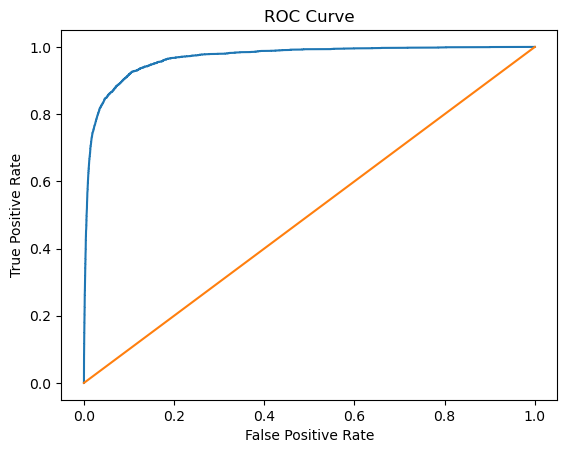

In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_eval, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

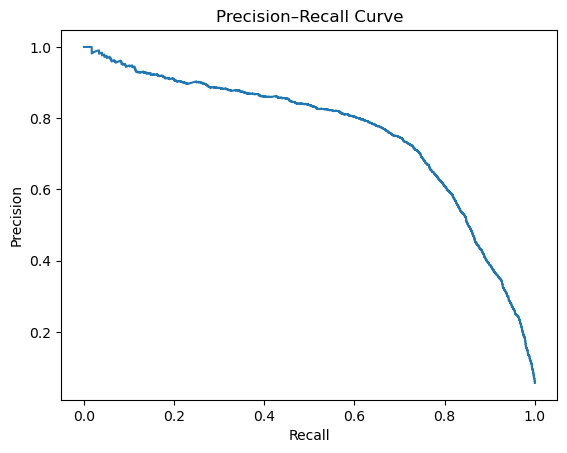

In [32]:
from sklearn.metrics import precision_recall_curve

p, r, _ = precision_recall_curve(y_eval, y_prob)

plt.figure()
plt.plot(r, p)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.show()

In [33]:
print(history.history.keys())

dict_keys(['auprc', 'auroc', 'loss', 'val_auprc', 'val_auroc', 'val_loss'])


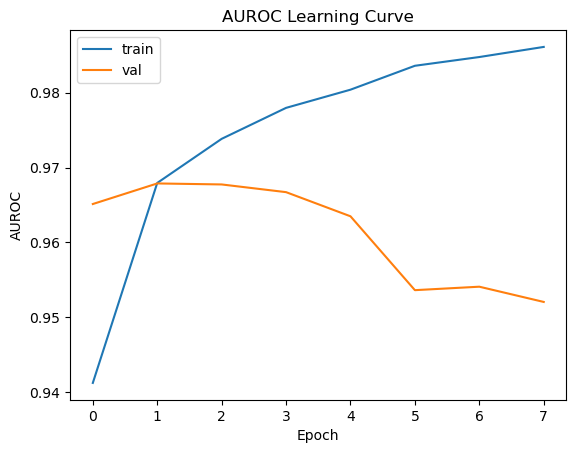

In [35]:
plt.figure()
plt.plot(history.history.get("auroc", []), label="train")
plt.plot(history.history.get("val_auroc", []), label="val")
plt.xlabel("Epoch")
plt.ylabel("AUROC")
plt.title("AUROC Learning Curve")
plt.legend()
plt.show()

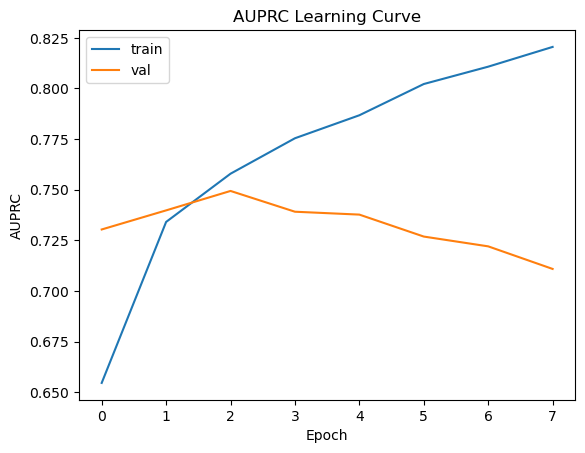

In [36]:
plt.figure()
plt.plot(history.history.get("auprc", []), label="train")
plt.plot(history.history.get("val_auprc", []), label="val")
plt.xlabel("Epoch")
plt.ylabel("AUPRC")
plt.title("AUPRC Learning Curve")
plt.legend()
plt.show()